<a href="https://colab.research.google.com/github/hanzalaakeel/NIAI_Cohort_2026/blob/main/NETSOL_AI_ML_Tasks/EDA_Worksheet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📝 EDA Worksheet — Auto-MPG Dataset
**Student Name:** Hanzala Akeel  |  **Date:** March 12, 2026

Complete every `# TODO` cell. Run the cells in order.  
Answer the written questions in the Markdown cells provided.

---
**Dataset:** Auto-MPG (UCI) | 398 rows × 9 columns


## Task 1 — Import Libraries

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

# Default figure size
plt.rcParams['figure.figsize'] = (10,5)

## Task 2 — Load & Inspect Data

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

col_names = ['mpg','cylinders','displacement','horsepower','weight',
             'acceleration','model_year','origin','car_name']

df = pd.read_csv(
    url,
    names=col_names,
    sep=r"\s+",
    na_values="?"
)

print("Shape:", df.shape)
df.head()

Shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [3]:
# TODO: Print df.info() to inspect dtypes and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


In [4]:
# TODO: Print df.describe() to view summary statistics
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


**Q1.** How many rows and columns does the dataset have?  
**Answer:** The dataset has 398 rows and 9 columns.

**Q2.** Which column contains missing values and how many?  
**Answer:** The 'horsepower' column contains 6 missing values.

## Task 3 — Pre-Processing

In [ ]:
# TODO: Check and print missing values per column
# Then drop all rows that contain NaN values (they are < 2% of data)
print(df.isnull().sum())

df = df.dropna()


mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64


In [ ]:
# TODO: Check for and remove duplicate rows
df = df.drop_duplicates()

In [ ]:
# TODO:
# 1. Convert 'cylinders' and 'model_year' to category dtype
# 2. Map 'origin' from {1,2,3} to {'usa','europe','japan'}
# 3. Strip & lowercase 'car_name'
df['cylinders'] = df['cylinders'].astype('category')
df['model_year'] = df['model_year'].astype('category')

df['origin'] = df['origin'].map({
    1:'usa',
    2:'europe',
    3:'japan'
})

df['car_name'] = df['car_name'].str.strip().str.lower()


In [ ]:
# TODO: Create two lists:
# cat_cols — categorical column names (cylinders, origin, model_year)
# num_cols — numerical column names (mpg, displacement, horsepower, weight, acceleration)

cat_cols = ['cylinders','origin','model_year']
num_cols = ['mpg','displacement','horsepower','weight','acceleration']

## Task 4 — Feature Engineering

In [ ]:
# TODO: Create 'mpg_level' column using pd.cut()
# Bins: [0,17) → 'low', [17,29) → 'medium', [29, max] → 'high'
df['mpg_level'] = pd.cut(
    df['mpg'],
    bins=[0,17,29,df['mpg'].max()],
    labels=['low','medium','high']
)

In [ ]:
# TODO: Create 'car_company' by extracting the first word from 'car_name'
df['car_company'] = df['car_name'].str.split().str[0]

## Task 5 — Categorical EDA

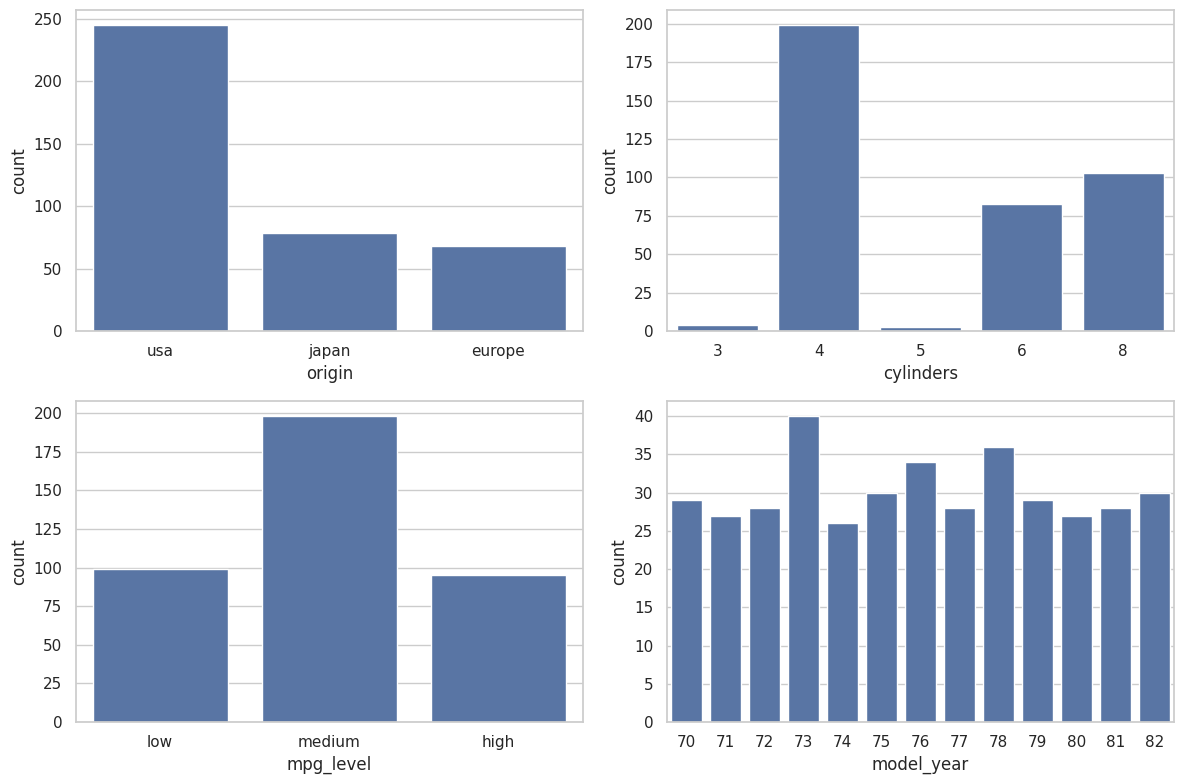

In [ ]:
# TODO: Plot a countplot for each of: origin, cylinders, mpg_level, model_year
# Arrange them in a 2×2 grid of subplots
fig, ax = plt.subplots(2,2, figsize=(12,8))

sns.countplot(data=df, x='origin', ax=ax[0,0])
sns.countplot(data=df, x='cylinders', ax=ax[0,1])
sns.countplot(data=df, x='mpg_level', ax=ax[1,0])
sns.countplot(data=df, x='model_year', ax=ax[1,1])

plt.tight_layout()
plt.show()

In [ ]:
# TODO: Print the proportion (%) of the dominant class for
# origin, cylinders, and mpg_level
for col in ['origin','cylinders','mpg_level']:
    prop = df[col].value_counts(normalize=True).max()*100
    print(f"{col} dominant class: {prop:.2f}%")

origin dominant class: 62.50%
cylinders dominant class: 50.77%
mpg_level dominant class: 50.51%


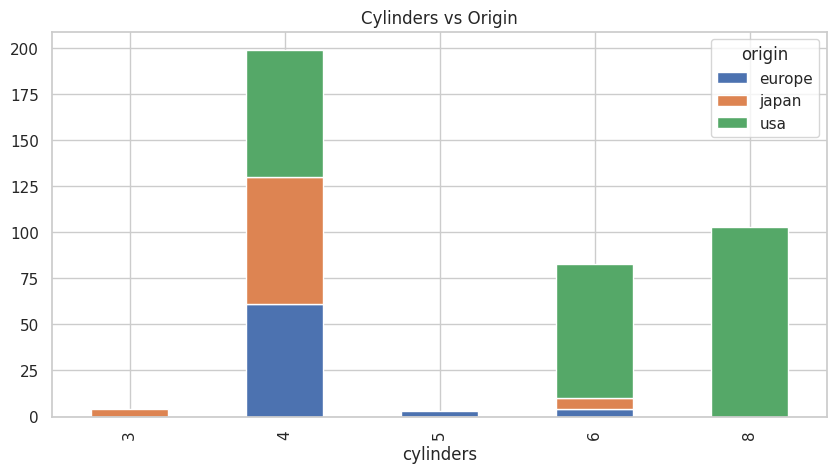

In [ ]:
# TODO: Create a crosstab of cylinders vs origin and visualise as a bar chart
ct = pd.crosstab(df['cylinders'], df['origin'])
ct.plot(kind='bar', stacked=True)
plt.title("Cylinders vs Origin")
plt.show()

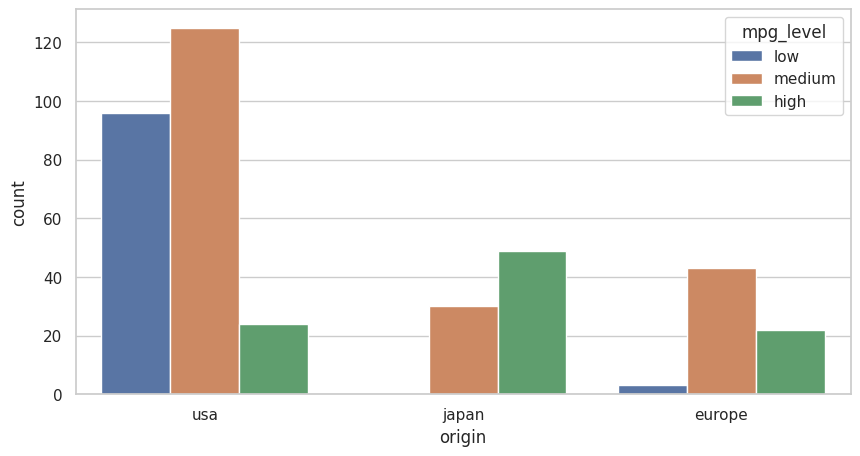

In [ ]:
# TODO: Plot a countplot of mpg_level grouped by origin (use hue='mpg_level')
sns.countplot(data=df, x='origin', hue='mpg_level')
plt.show()

**Q3.** Which origin has **no** vehicles with low mpg_level?  
**Answer:** Europe and Japan

**Q4.** Which cylinder count is most common, and what percentage does it represent?  
**Answer:** 4 cylinders, representing 50.77%

## Task 6 — Numerical EDA

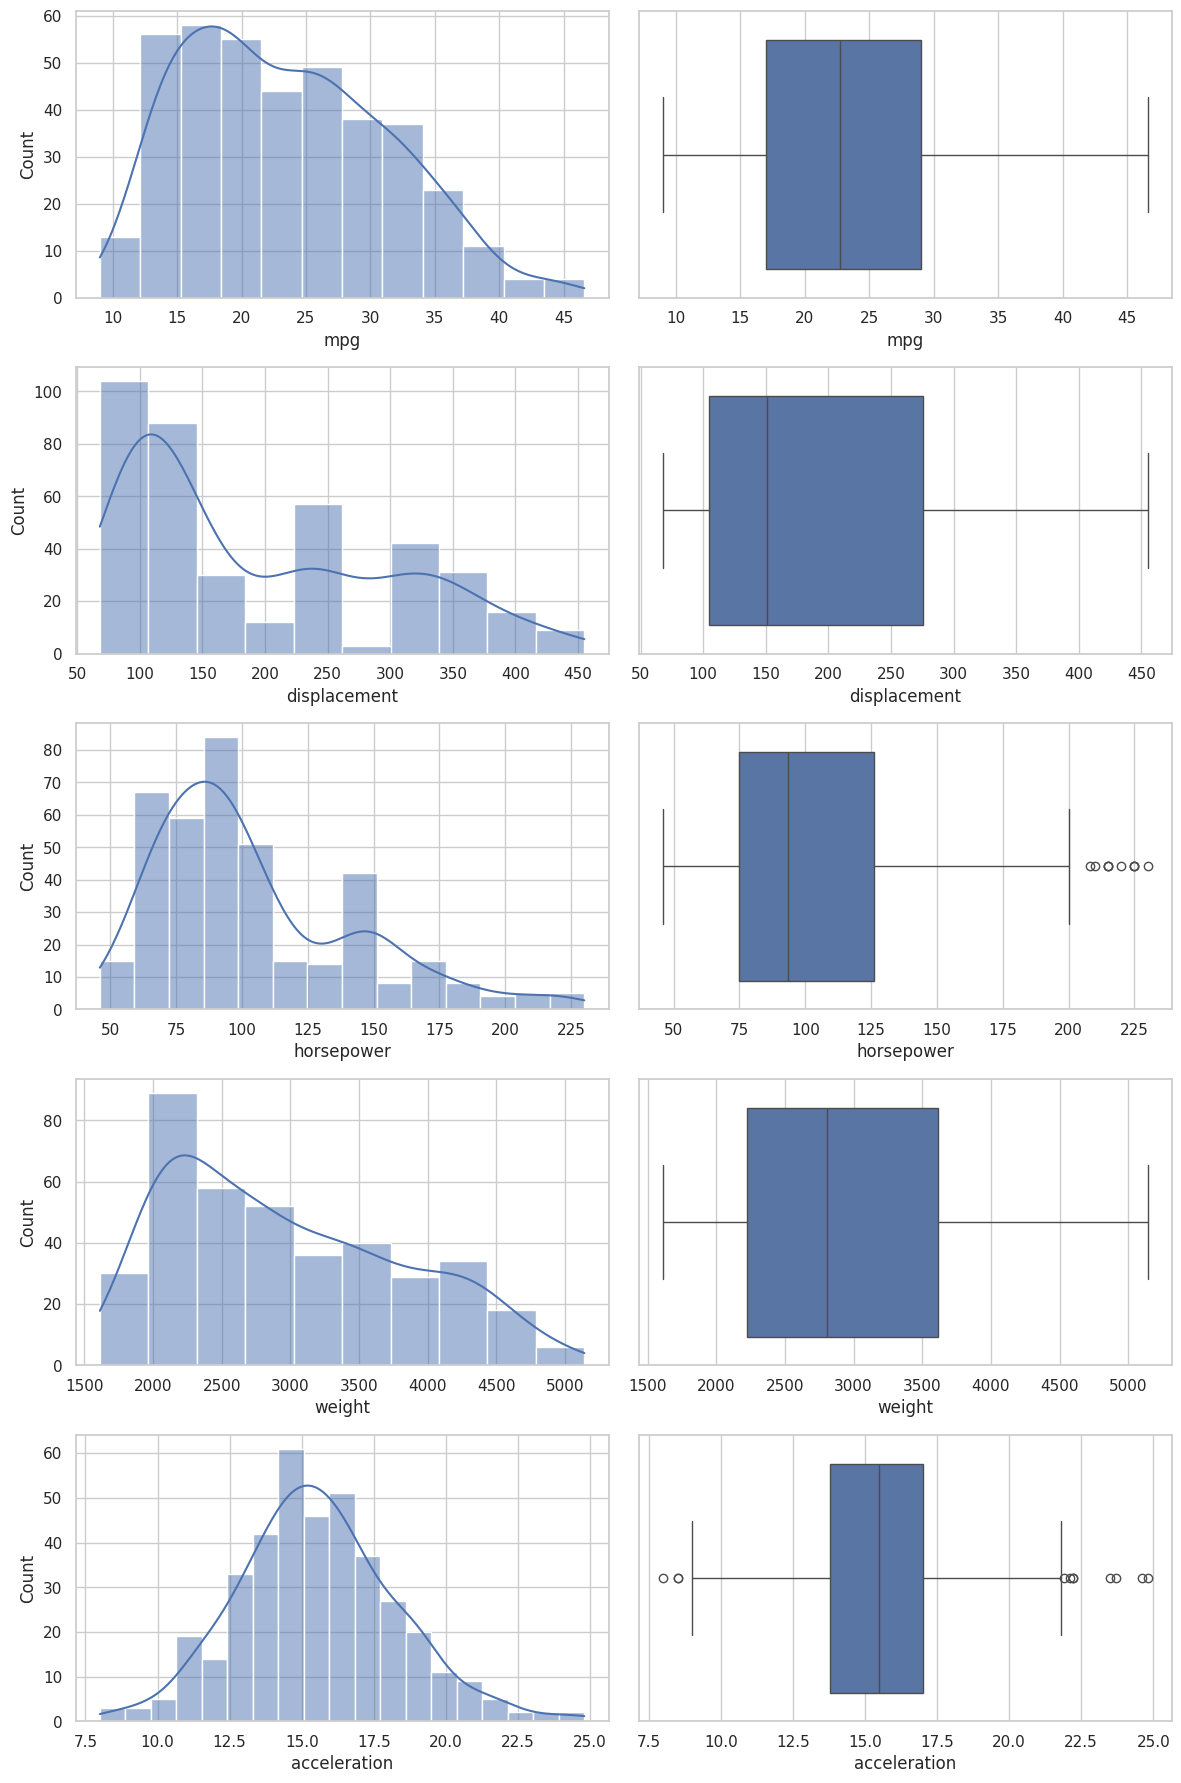

In [ ]:
# TODO: For each numerical column plot:
#   (a) Histogram + KDE  (b) Boxplot
# Arrange in a grid (n_cols rows × 2 columns)
fig, axes = plt.subplots(len(num_cols),2, figsize=(12,18))

for i,col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i,0])
    sns.boxplot(x=df[col], ax=axes[i,1])

plt.tight_layout()
plt.show()


In [ ]:
# TODO: Write a function tukey_outliers(series) that returns the outlier values
# using the IQR (Tukey) rule: Q1 - 1.5*IQR  and  Q3 + 1.5*IQR
# Then print the outlier count for each numerical column

def tukey_outliers(series):

    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    return series[(series < lower) | (series > upper)]

for col in num_cols:
    print(col, len(tukey_outliers(df[col])))

mpg 0
displacement 0
horsepower 10
weight 0
acceleration 11


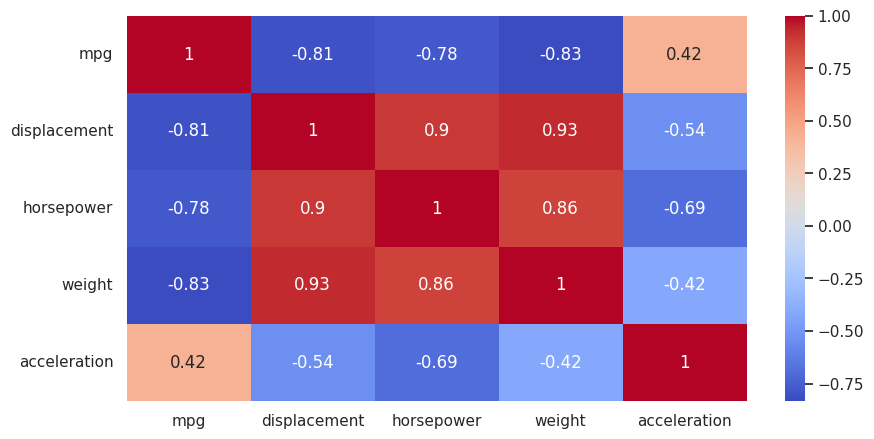

In [ ]:
# TODO: Plot a correlation heatmap for all numerical columns (use annot=True)
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

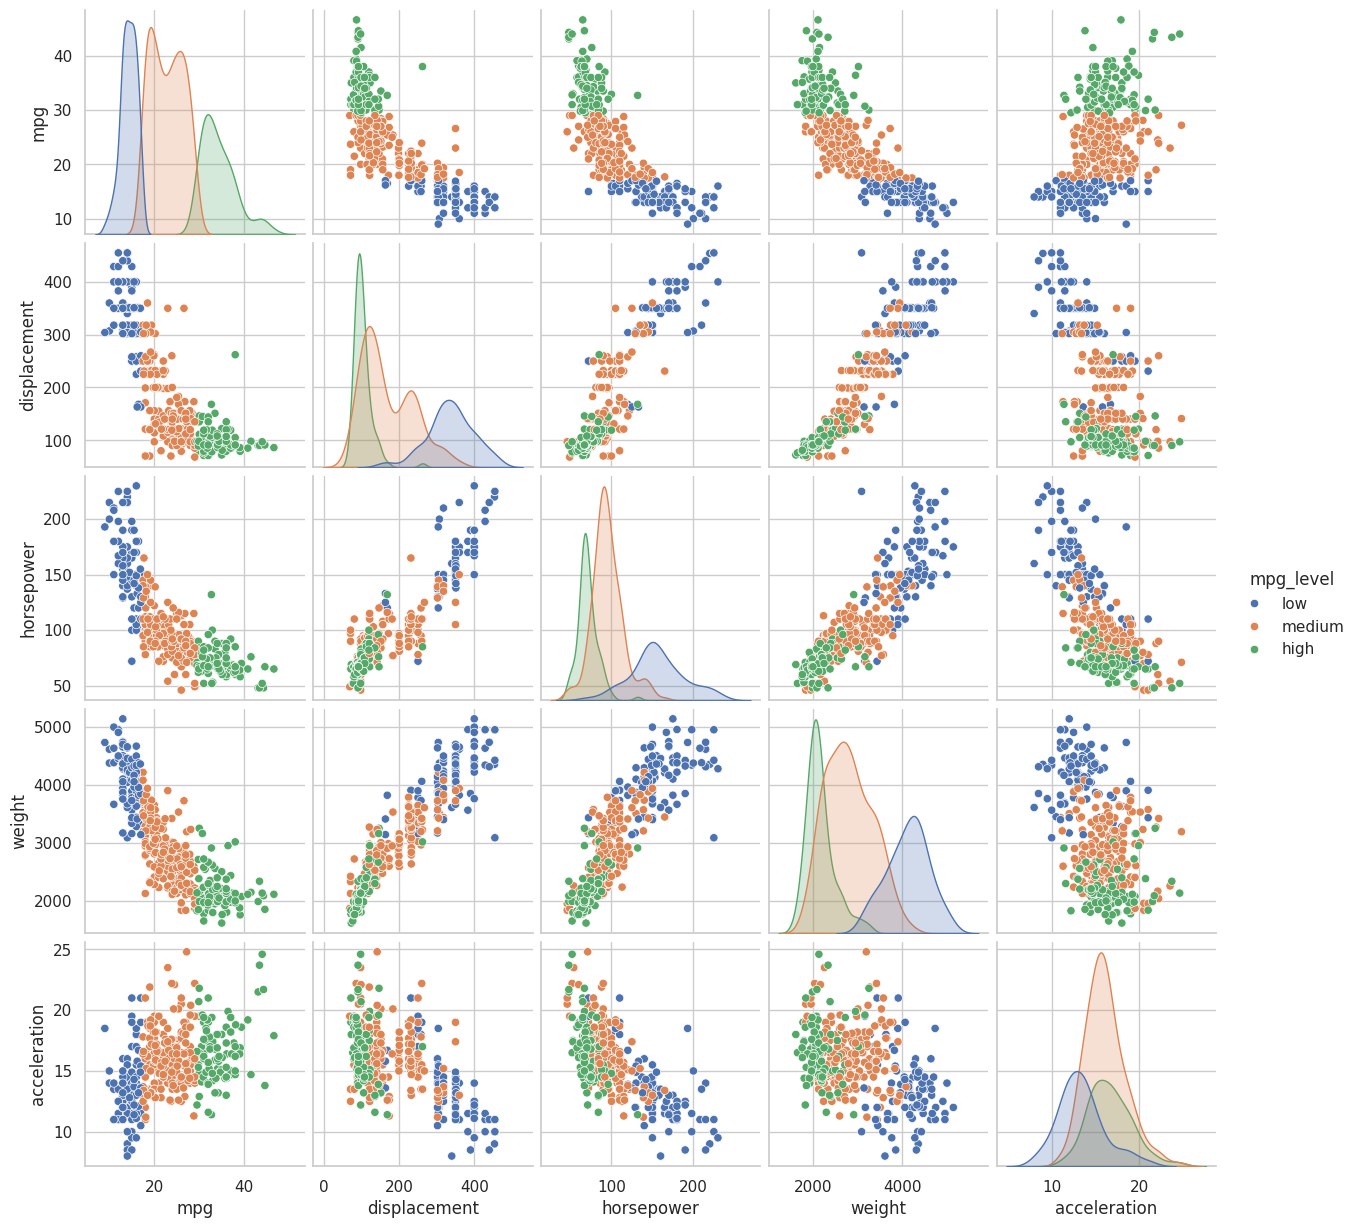

In [ ]:
# TODO: Create a pairplot of numerical columns, coloured by mpg_level
sns.pairplot(df[num_cols + ['mpg_level']], hue='mpg_level')
plt.show()

**Q5.** Which two numerical features have the strongest negative correlation with mpg?  
**Answer:** Weight and Displacement

**Q6.** Is the `acceleration` distribution approximately Gaussian? Justify briefly.  
**Answer:** Yes, the `acceleration` distribution is approximately Gaussian. The histogram and KDE plot for acceleration generally show a symmetric, bell-shaped curve, with the mean and median being very close, which are characteristics of a normal (Gaussian) distribution.

## Task 7 — Numerical vs Categorical

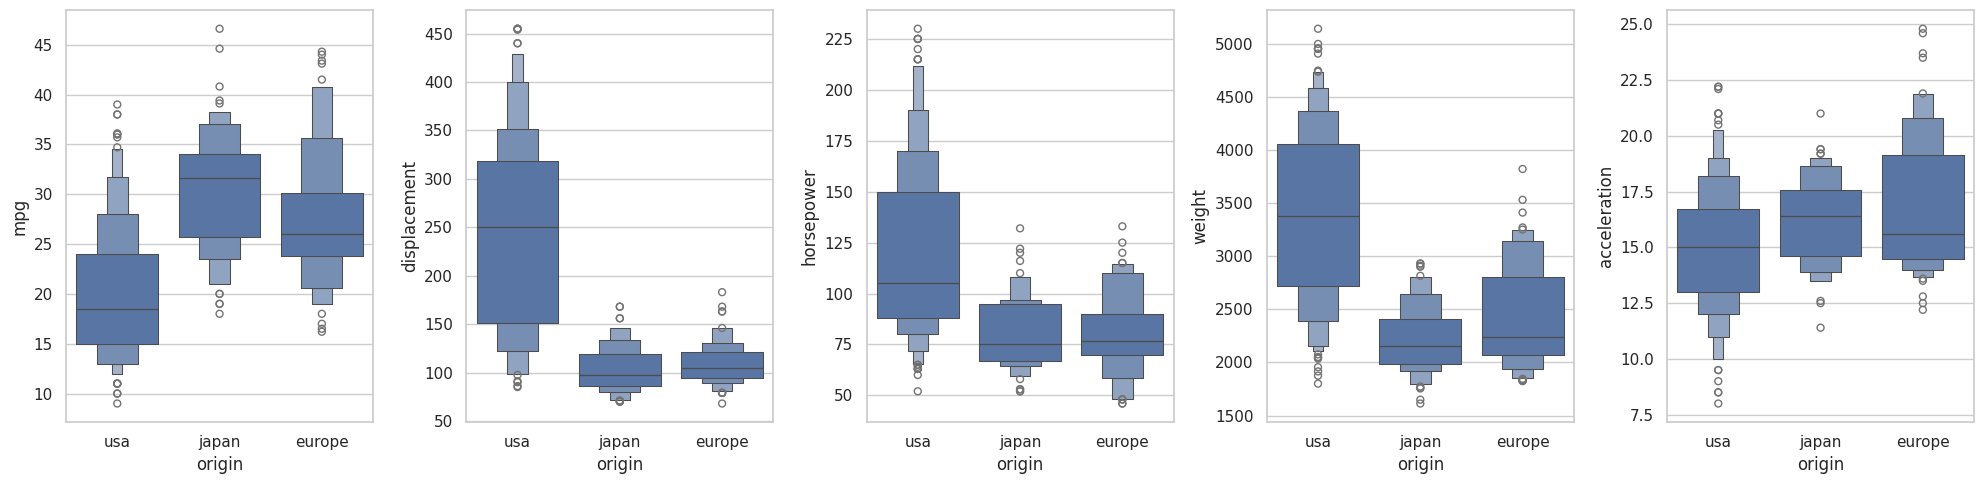

In [ ]:
# TODO: Plot boxenplots of all numerical features grouped by 'origin'
# (1 row × 5 column subplot grid)
fig, ax = plt.subplots(1,5, figsize=(20,5))

for i,col in enumerate(num_cols):
    sns.boxenplot(data=df, x='origin', y=col, ax=ax[i])

plt.tight_layout()
plt.show()

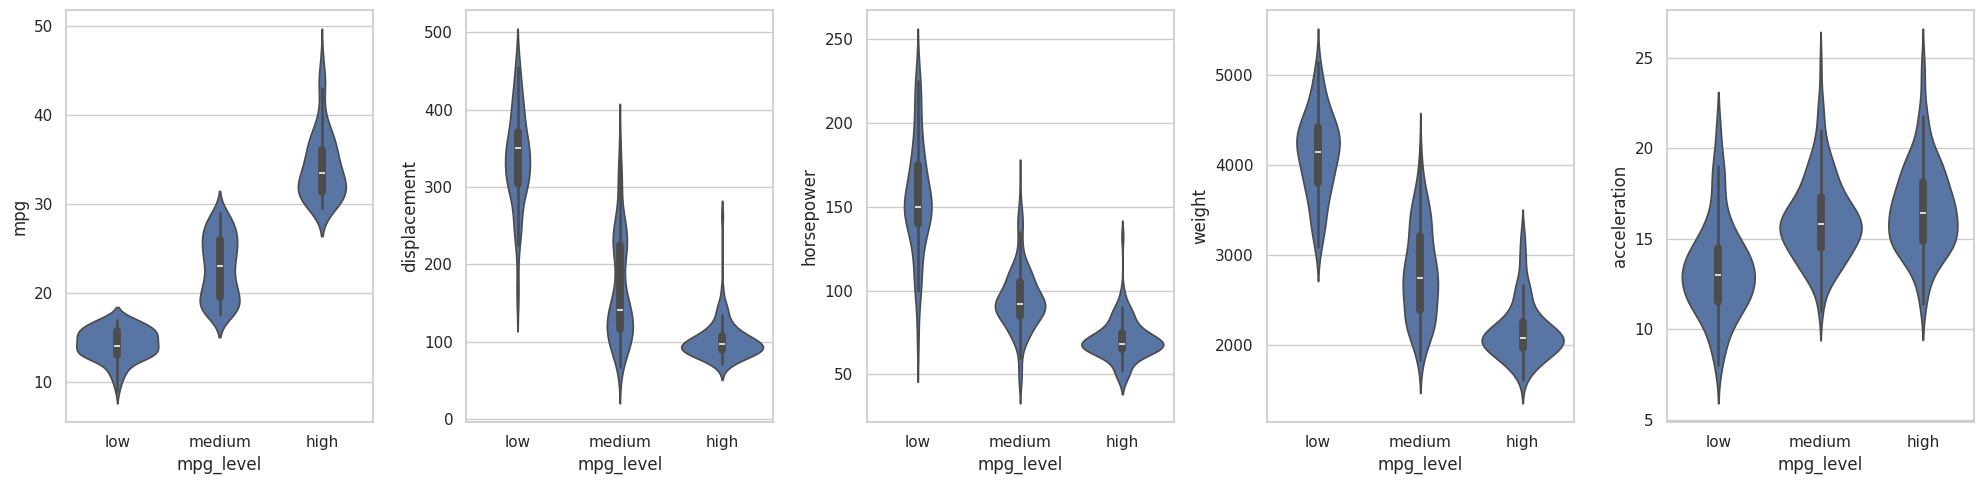

In [ ]:
# TODO: Plot violinplots of all numerical features grouped by 'mpg_level'
fig, ax = plt.subplots(1,5, figsize=(20,5))

for i,col in enumerate(num_cols):
    sns.violinplot(data=df, x='mpg_level', y=col, ax=ax[i])

plt.tight_layout()
plt.show()

/tmp/ipykernel_969/1990532018.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('model_year')['mpg'].mean().plot(marker='o')


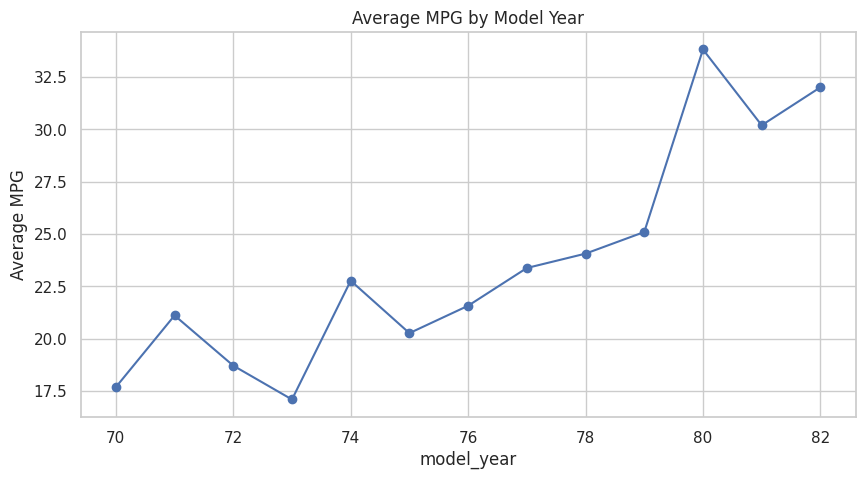

In [ ]:
# TODO: Plot a line chart showing mean mpg per model_year
df.groupby('model_year')['mpg'].mean().plot(marker='o')
plt.ylabel("Average MPG")
plt.title("Average MPG by Model Year")
plt.show()

**Q7.** On average, which origin produces cars with the lowest mpg?  
**Answer:** USA

**Q8.** Describe in one sentence how mpg changes as model_year increases.  
**Answer:** As the model year increases, the average miles per gallon (mpg) generally increases, indicating improved fuel efficiency over time.

## Task 8 — Summary Table
Fill in the table below based on your analysis.

| Feature | Relationship with MPG | Strength |
|---|---|---|
| displacement | | |
| horsepower | | |
| weight | | |
| acceleration | | |
| cylinders | | |
| origin | | |
| model_year | | |
